In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



To upload the `spam.csv` file, please run the following cell and select the file from your local machine. This will make the file available in the Colab environment.

In [5]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [6]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [7]:
df.shape

(5572, 5)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [9]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [10]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [11]:
df.rename(columns={'v1':'target','v2':'msg'})

,target,msg
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
enc=LabelEncoder()

In [14]:
df.rename(columns={'v1':'target','v2':'msg'},inplace=True)

In [15]:
enc.fit_transform(df['target'])

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [16]:
df

,target,msg
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [17]:
df['target']=enc.fit_transform(df['target'])

In [18]:
df

,target,msg
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [19]:
df.isnull().sum()

target    0
msg       0
dtype: int64

In [20]:
#checking duplicates

In [21]:
df.duplicated().sum()

np.int64(403)

In [22]:
#removing duplicates

In [23]:
df.drop_duplicates(keep='first')

,target,msg
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [24]:
df=df.drop_duplicates(keep='first')

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.head()

,target,msg
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [27]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [28]:
import matplotlib.pyplot as plt

([<matplotlib.patches.Wedge at 0x147e87fef90>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

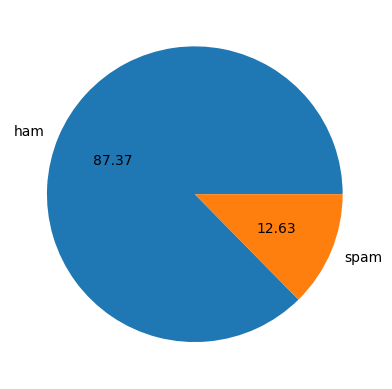

In [29]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%.2f")

In [30]:
import nltk


In [31]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Saras\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [32]:
df['msg'].apply(len)

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: msg, Length: 5169, dtype: int64

In [33]:
df['char_count']=df['msg'].apply(len)

In [34]:
df.head()

,target,msg,char_count
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [35]:
nltk.download('punkt_tab')
df['msg'].apply(lambda x:nltk.word_tokenize(x))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Saras\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: msg, Length: 5169, dtype: object

In [36]:
df['word_count']=df['msg'].apply(lambda x:len(nltk.word_tokenize(x)))

In [37]:
df.head()

,target,msg,char_count,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [38]:
df['sent_count']=df['msg'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [39]:
df.head()

,target,msg,char_count,word_count,sent_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [40]:
df[['sent_count','word_count','char_count']].describe()

,sent_count,word_count,char_count
count,5169.000000,5169.000000,5169.000000
mean,1.965564,18.455794,78.977945
std,1.448541,13.324758,58.236293
min,1.000000,1.000000,2.000000
25%,1.000000,9.000000,36.000000
50%,1.000000,15.000000,60.000000
75%,2.000000,26.000000,117.000000
max,38.000000,220.000000,910.000000


In [41]:
df[df['target']==0][['sent_count','word_count','char_count']].describe()

,sent_count,word_count,char_count
count,4516.000000,4516.000000,4516.000000
mean,1.820195,17.123782,70.459256
std,1.383657,13.493970,56.358207
min,1.000000,1.000000,2.000000
25%,1.000000,8.000000,34.000000
50%,1.000000,13.000000,52.000000
75%,2.000000,22.000000,90.000000
max,38.000000,220.000000,910.000000


In [42]:
df[df['target']==1][['sent_count','word_count','char_count']].describe()

,sent_count,word_count,char_count
count,653.000000,653.000000,653.000000
mean,2.970904,27.667688,137.891271
std,1.488425,7.008418,30.137753
min,1.000000,2.000000,13.000000
25%,2.000000,25.000000,132.000000
50%,3.000000,29.000000,149.000000
75%,4.000000,32.000000,157.000000
max,9.000000,46.000000,224.000000


<Axes: xlabel='char_count', ylabel='Count'>

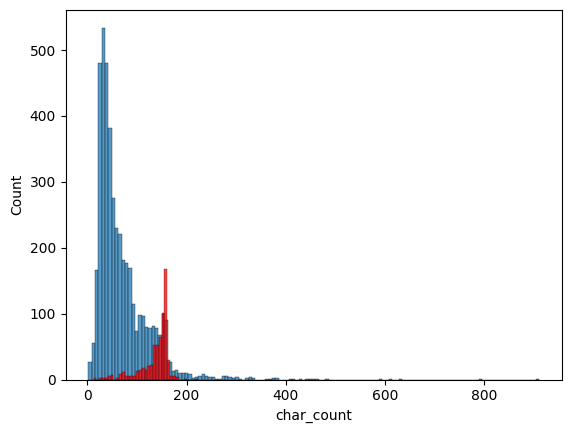

In [43]:
sns.histplot(df[df['target']==0]['char_count'])
sns.histplot(df[df['target']==1]['char_count'],color='red')

<Axes: xlabel='word_count', ylabel='Count'>

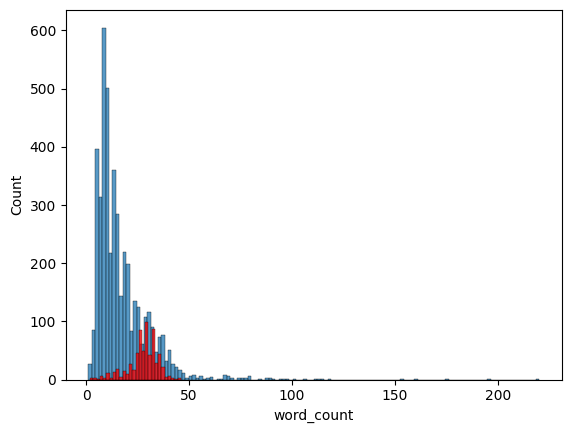

In [44]:
sns.histplot(df[df['target']==0]['word_count'])
sns.histplot(df[df['target']==1]['word_count'],color='red')

<Axes: xlabel='sent_count', ylabel='Count'>

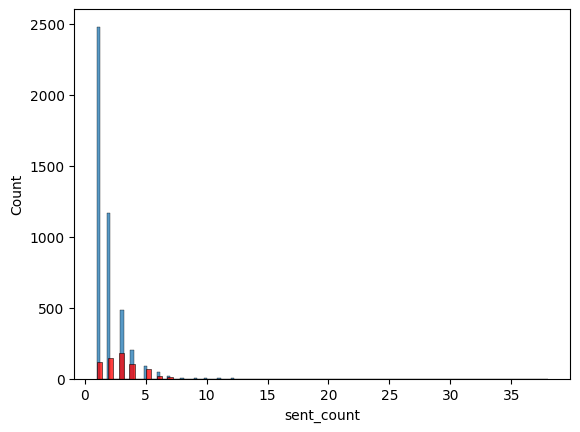

In [45]:
sns.histplot(df[df['target']==0]['sent_count'])
sns.histplot(df[df['target']==1]['sent_count'],color='red')

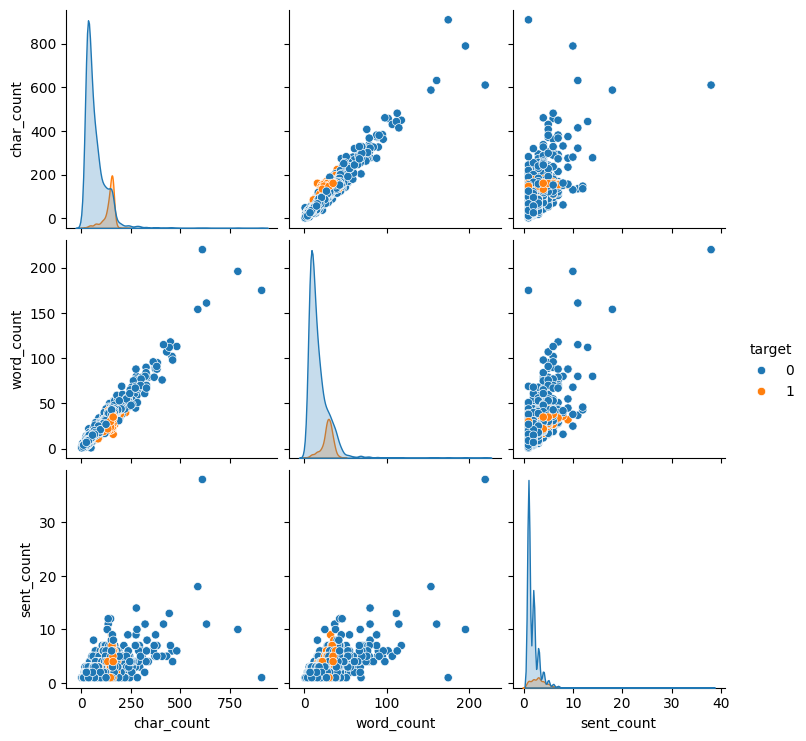

In [46]:
sns.pairplot(df,hue='target')

In [47]:
y=df['msg']

In [48]:
df.drop(columns=['msg'],inplace=True)

<Axes: >

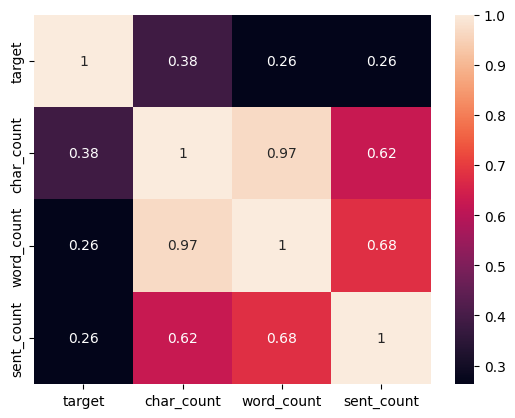

In [49]:
sns.heatmap(df.corr(),annot=True)

In [50]:
df['msg']=y

In [51]:
df.head()

,target,char_count,word_count,sent_count,msg
0,0,111,24,2,"Go until jurong point, crazy.. Available only ..."
1,0,29,8,2,Ok lar... Joking wif u oni...
2,1,155,37,2,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,49,13,1,U dun say so early hor... U c already then say...
4,0,61,15,1,"Nah I don't think he goes to usf, he lives aro..."


In [52]:
nltk.download('stopwords')
stopwords=nltk.corpus.stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Saras\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [53]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [54]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [55]:
def transform_text(text):
  text=text.lower()
  text=nltk.word_tokenize(text)
  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)
  text=y[:]
  y.clear()
  for i in text:
    if i not in stopwords and i not in string.punctuation:
      y.append(i)
  text=y[:]
  y.clear()
  for i in text:
    y.append(ps.stem(i))
  return " ".join(y)

In [56]:
df['trans_text']=df['msg'].apply(transform_text)

In [57]:
df

,target,char_count,word_count,sent_count,msg,trans_text
0,0,111,24,2,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,29,8,2,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,155,37,2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,49,13,1,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,61,15,1,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,161,35,4,This is the 2nd time we have tried 2 contact u...,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,37,9,1,Will Ì_ b going to esplanade fr home?,b go esplanad fr home
5569,0,57,15,2,"Pity, * was in mood for that. So...any other s...",piti mood suggest
5570,0,125,27,1,The guy did some bitching but I acted like i'd...,guy bitch act like interest buy someth els nex...


In [58]:
from wordcloud import WordCloud

In [59]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [60]:
spam_wc=wc.generate(df[df['target']==1]['trans_text'].str.cat(sep=' '))

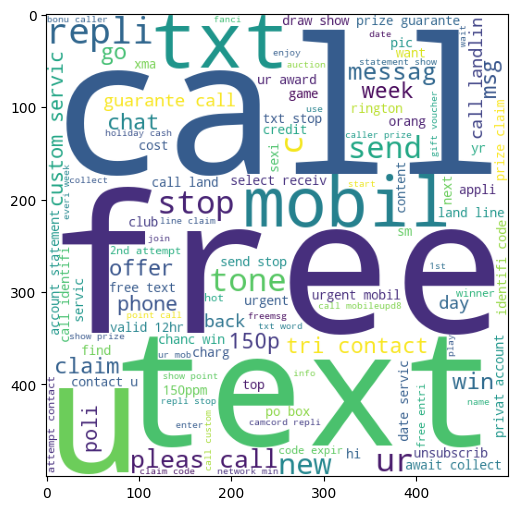

In [61]:
plt.figure(figsize=(12,6))
plt.imshow(spam_wc)

In [62]:
ham_wc=wc.generate(df[df['target']==0]['trans_text'].str.cat(sep=' '))

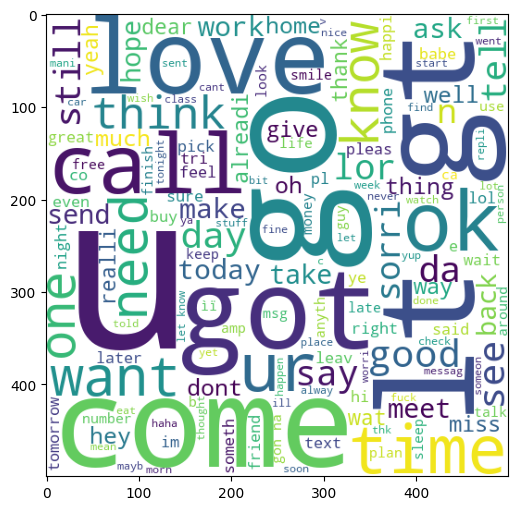

In [63]:
plt.figure(figsize=(12,6))
plt.imshow(ham_wc)

In [64]:
spam_corpus=[]
for sentence in df[df['target']==1]['trans_text'].tolist():
  for word in sentence.split():
    spam_corpus.append(word)

In [65]:
len(spam_corpus)

9939

In [66]:
from collections import Counter

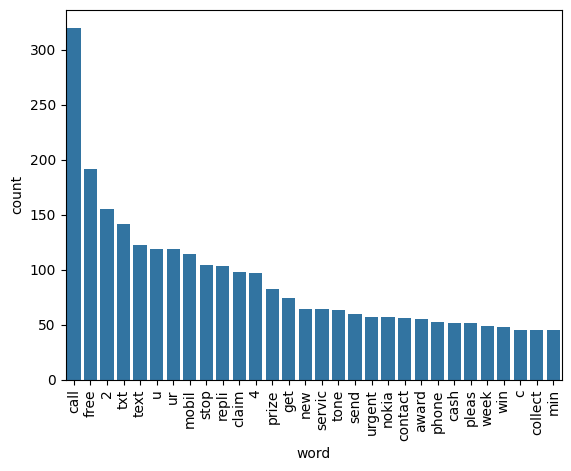

In [67]:
most_common_spam_words = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(x='word', y='count', data=most_common_spam_words)
plt.xticks(rotation='vertical')
plt.show()

In [68]:
ham_corpus=[]
for sentence in df[df['target']==0]['trans_text'].tolist():
  for word in sentence.split():
    ham_corpus.append(word)

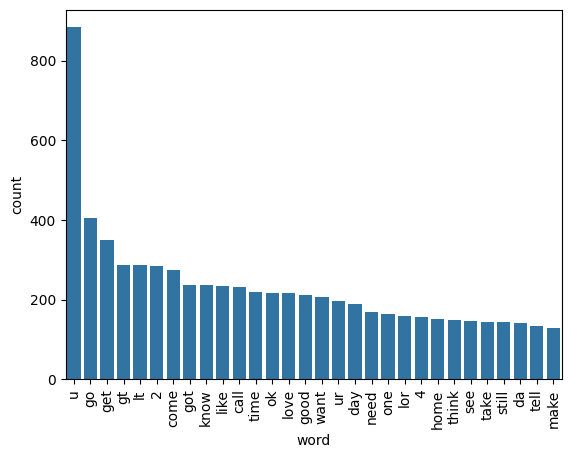

In [69]:
most_common_ham_words = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(x='word', y='count', data=most_common_ham_words)
plt.xticks(rotation='vertical')
plt.show()

In [70]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [71]:
cv=CountVectorizer()
tf=TfidfVectorizer()

In [72]:
x=tf.fit_transform(df['trans_text']).toarray()

In [73]:
x.shape

(5169, 6708)

In [74]:
y=df['target'].values

In [75]:
from sklearn.model_selection import train_test_split

In [76]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [77]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [78]:
gnb=GaussianNB()

In [79]:
mnb=MultinomialNB()
bnb=BernoulliNB()

In [80]:
gnb.fit(x_train,y_train)
y_pred1=gnb.predict(x_test)

In [81]:
mnb.fit(x_train,y_train)
y_pred2=mnb.predict(x_test)

In [82]:
bnb.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3620., 515.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.13,-2.08]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 6708)","[[ 0., 0., 0.,..., 0., 0.,41.], [ 0., 1., 1.,..., 0., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 6708)","[[-8.19,-8.19,-8.19,...,-8.19,-8.19,-4.46], [-6.25,-5.55,-5.55,...,-6.25,-6.25,-6.25]]"


In [83]:
ypred3=bnb.predict(x_test)

In [84]:
from sklearn.metrics import r2_score,accuracy_score,confusion_matrix,precision_score

In [85]:
accuracy_score(y_test,y_pred1)

0.8762088974854932

In [86]:
confusion_matrix(y_test,y_pred1)

array([[793, 103],
       [ 25, 113]])

In [87]:
precision_score(y_test,y_pred1)

0.5231481481481481

In [88]:
#mnb

In [89]:
accuracy_score(y_test,y_pred2)

0.9593810444874274

In [90]:
precision_score(y_test,y_pred2)
confusion_matrix(y_test,y_pred2)

array([[896,   0],
       [ 42,  96]])

In [91]:
precision_score(y_test,y_pred2)

1.0

In [92]:
#BNB

In [93]:
print(accuracy_score(y_test,ypred3))
print(confusion_matrix(y_test,ypred3))
print(precision_score(y_test,ypred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [94]:
#TFIDF with MNB

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [96]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')

In [97]:
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)


In [98]:
clfs={'SVC':svc,'KN':knc,'DT':dtc,'LR':lrc,'RF':rfc,'AdaBoost':abc,'BgC':bc,'ETC':etc,'GBDT':gbdt,'xgb':xgb,'NB':mnb}

In [99]:
from nltk.metrics.scores import precision
def train_classifier(svc,x_train,y_train,y_test):
  svc.fit(x_train,y_train)
  y_pred=svc.predict(x_test)
  return precision_score(y_test,y_pred),accuracy_score(y_test,y_pred)

In [101]:
accuracy=[]
precision=[]
for i in clfs:
  current_precision,current_accuracy=train_classifier(clfs[i],x_train,y_train,y_test)
  accuracy.append(current_accuracy)
  precision.append(current_precision)

  

c:\Users\Saras\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Saras\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [102]:
performance=pd.DataFrame({'Algorithms':clfs.keys(),'Accuracy':accuracy,'Precision':precision})

In [103]:
performance

,Algorithms,Accuracy,Precision
0,SVC,0.972921,0.974138
1,KN,0.900387,1.000000
2,DT,0.934236,0.830189
3,LR,0.951644,0.940000
4,RF,0.971954,1.000000
5,AdaBoost,0.924565,0.840909
6,BgC,0.958414,0.862595
7,ETC,0.972921,0.982456
8,GBDT,0.951644,0.923077
9,xgb,0.974855,0.951613


In [104]:
import pickle

In [105]:
pickle.dump(tf,open('vectorizer.pkl','wb'))

In [106]:
pickle.dump(mnb,open('model.pkl','wb'))